Computing verification metrics.

In [1]:
import numpy as np
import xarray as xr
import os
from matplotlib import pyplot as plt
from tqdm import tqdm
from wavediffusion.waveana import assemble 
import cartopy.crs as ccrs
from wavediffusion.waveana import add_lat_lon

%load_ext autoreload
%autoreload 2

In [4]:
############ Prepare mask and lat weights ############
# Weights computed and saved with wavedata.ipynb
wlat = np.load('/global/homes/j/jiarongw/scratch_folder/wave_data/wlat.npy')
# weighted and masked RMSE
def weighted_mse(a, b, mask, w):
    diff2 = (a - b) ** 2
    return np.sum(diff2[mask] * w[mask]) / np.sum(w[mask])
# weighted and masked spread / skill
def weighted_meanvar(std, mask, w):
    var = std ** 2
    return np.sum(var[mask] * w[mask]) / np.sum(w[mask])    

In [5]:
# mean
# OPTION = 1
# case = '_moredata'
# epoch = 18

# derived
OPTION = 2
case = '_nohist'
# case = ''
epoch = 8

# partition
# OPTION = 3
# case = '_resume'
# case = ''
# epoch = 10

# Time 
# year = 2004
# month = 4
# path = f'/global/homes/j/jiarongw/scratch_folder/final/temp/OPTION{OPTION}{case}_sigma100_epoch{epoch}_{year}{month:02d}/'
# print(f'Reading from {path} snapshot {year}-{month:02d}...')

# Or a whole year
year = 2004
path = f'/global/homes/j/jiarongw/scratch_folder/final/temp/OPTION{OPTION}{case}_sigma100_epoch{epoch}_{year}/'
print(f'Reading from {path} snapshot {year}...')

if OPTION == 1:
    var_names = ['hs', 'tm', 'dir']
elif OPTION == 2:
    var_names = ['hs', 'uss', 'vss', 'mssd', 'mssc']
elif OPTION == 3:
    var_names = ['hs_p1', 'tp_p1', 'thetap_p1', 'hs_p2', 'tp_p2', 'thetap_p2', 'ci']

Reading from /global/homes/j/jiarongw/scratch_folder/final/temp/OPTION2_nohist_sigma100_epoch8_2004/ snapshot 2004...


### MSE and SSR

In [6]:
mse_vars = {name: [] for name in var_names}
mse_sample_vars = {name: [] for name in var_names}
std_vars = {name: [] for name in var_names}
# 
# for index in tqdm(range(0, 200, 8)):   
for index in tqdm(range(0, 2840, 40)):
    x_truth = np.load(f'{path}truth_{index}.npy')
    x_sample = np.load(f'{path}sample_{index}.npy')
    x_mean = np.load(f'{path}mean_{index}.npy')
    std = np.load(f'{path}std_{index}.npy')
    icymask = np.load(f'{path}icymask_{index}.npy')

    # Use the ice mask?
    for name in var_names:
         mse_vars[name].append(weighted_mse(x_truth[var_names.index(name)], x_mean[var_names.index(name)], icymask, wlat))
         mse_sample_vars[name].append(weighted_mse(x_truth[var_names.index(name)], x_sample[var_names.index(name)], icymask, wlat))        
         std_vars[name].append(weighted_meanvar(std[var_names.index(name)], icymask, wlat))

for name in var_names:
    mse_vars[name] = np.array(mse_vars[name])
    mse_sample_vars[name] = np.array(mse_sample_vars[name])
    std_vars[name] = np.array(std_vars[name])
    print(f'{name} mean rmse: {mse_vars[name].mean()**0.5:.4f} \\pm {np.std(mse_vars[name]**0.5):.4f}')
    # print(f'{name} sample rmse: {mse_sample_vars[name].mean()**0.5:.4f} \\pm {np.std(mse_sample_vars[name]**0.5):.4f}')
    print(f'{name} ssr: {(std_vars[name].mean() / mse_vars[name].mean())**0.5:.4f}')    

100%|██████████| 71/71 [00:02<00:00, 27.19it/s]

hs mean rmse: 0.5909 \pm 0.0502
hs ssr: 0.7170
uss mean rmse: 0.0103 \pm 0.0007
uss ssr: 1.0179
vss mean rmse: 0.0099 \pm 0.0007
vss ssr: 0.9455
mssd mean rmse: 0.0010 \pm 0.0001
mssd ssr: 0.5939
mssc mean rmse: 0.0008 \pm 0.0001
mssc ssr: 0.6130


### ACC

In [7]:
BY_MONTH = False

In [14]:
# acc_OPTION = 1
# acc_case = '_moredata'
# acc_epoch = 20
# acc_year = 2004
# acc_month = 4
# acc_var_names = ['hs', 'tm', 'dir']
# acc_path = f'/global/homes/j/jiarongw/scratch_folder/final/temp/OPTION{acc_OPTION}{acc_case}_sigma100_epoch{acc_epoch}_{acc_year:04d}{acc_month:02d}/'
# clim_ds = xr.open_dataset(os.path.expanduser('~/scratch_folder/final/processed/mean_clim_monthly.nc')).load().assign_coords(month=np.arange(1, 13))

acc_OPTION = 2
# acc_case = '_nohist'
acc_case = ''
acc_epoch = 8
acc_year = 2004
acc_var_names = ['hs', 'uss', 'vss', 'mssd', 'mssc']
if BY_MONTH:
    acc_month = 4
    acc_path = f'/global/homes/j/jiarongw/scratch_folder/final/temp/OPTION{acc_OPTION}{acc_case}_sigma100_epoch{acc_epoch}_{acc_year:04d}{acc_month:02d}/'
else:
    acc_path = f'/global/homes/j/jiarongw/scratch_folder/final/temp/OPTION{acc_OPTION}{acc_case}_sigma100_epoch{acc_epoch}_{acc_year:04d}/'    
# month dimension has no real coordinate in the saved file (it's just positional, index 0 = January .. index 11 = December)
# so assign explicit calendar-month labels here for correct .sel(month=...) lookups
clim_ds = xr.open_dataset(os.path.expanduser('~/scratch_folder/final/processed/derived_clim_monthly.nc')).load().assign_coords(month=np.arange(1, 13))

# acc_OPTION = 3
# acc_case = ''
# acc_epoch = 10
# acc_year = 2004
# acc_month = 4
# acc_var_names = ['hs_p1', 'tp_p1', 'thetap_p1', 'hs_p2', 'tp_p2', 'thetap_p2', 'ci', ]
# acc_path = f'/global/homes/j/jiarongw/scratch_folder/final/temp/OPTION{acc_OPTION}{acc_case}_sigma100_epoch{acc_epoch}_{acc_year:04d}{acc_month:02d}/'
# clim_ds = xr.open_dataset(os.path.expanduser('~/scratch_folder/final/processed/partition_clim_monthly.nc')).load().assign_coords(month=np.arange(1, 13))


def weighted_acc(fcst, obs, mask, w):
    valid = mask & np.isfinite(fcst) & np.isfinite(obs)
    if not np.any(valid):
        return np.nan
    wv = w[valid]
    f = fcst[valid]
    o = obs[valid]
    cov = np.sum(f * o * wv) / np.sum(wv)
    var_f = np.sum(f**2 * wv) / np.sum(wv)
    var_o = np.sum(o**2 * wv) / np.sum(wv)
    denom = np.sqrt(var_f * var_o)
    return cov / denom if denom > 0 else np.nan

In [20]:
acc_results = {name: [] for name in acc_var_names}

for index in tqdm(range(0, 200, 8)):
    x_truth = np.load(f'{acc_path}truth_{index}.npy')
    x_mean = np.load(f'{acc_path}mean_{index}.npy')
    icymask = np.load(f'{acc_path}icymask_{index}.npy')
    for name in acc_var_names:
        clim = clim_ds[name].sel(month=acc_month).values
        truth_anom = x_truth[acc_var_names.index(name)] - clim
        mean_anom = x_mean[acc_var_names.index(name)] - clim
        acc_results[name].append(weighted_acc(mean_anom, truth_anom, icymask, wlat))

for name, values in acc_results.items():
    values = np.array(values)
    print(f'{name} ACC: {np.nanmean(values):.6f} ± {np.nanstd(values):.6f}')

100%|██████████| 25/25 [00:00<00:00, 71.21it/s]

hs_p1 ACC: 0.901172 ± 0.013241
tp_p1 ACC: 0.615673 ± 0.044539
thetap_p1 ACC: 0.755535 ± 0.028873
hs_p2 ACC: 0.690131 ± 0.028713
tp_p2 ACC: 0.450167 ± 0.044442
thetap_p2 ACC: 0.512474 ± 0.039537
ci ACC: 0.652009 ± 0.040153


In [15]:
############ ACC for a full year, monthly climatology looked up by index ############
import pandas as pd

# Whole-year sample directory (no month in the folder name)

acc_results_year = {name: [] for name in acc_var_names}
acc_results_by_month = {name: {m: [] for m in range(1, 13)} for name in acc_var_names}

for index in tqdm(range(0, 2840, 40)):
    # Each index is a 3-hour timestep from the start of the year; use it to look up the month
    timestamp = pd.Timestamp(acc_year, 1, 1) + pd.Timedelta(hours=3 * index)
    month = timestamp.month

    x_truth = np.load(f'{acc_path}truth_{index}.npy')
    x_mean = np.load(f'{acc_path}mean_{index}.npy')
    icymask = np.load(f'{acc_path}icymask_{index}.npy')

    for name in acc_var_names:
        clim = clim_ds[name].sel(month=month).values
        truth_anom = x_truth[acc_var_names.index(name)] - clim
        mean_anom = x_mean[acc_var_names.index(name)] - clim
        acc = weighted_acc(mean_anom, truth_anom, icymask, wlat)
        acc_results_year[name].append(acc)
        acc_results_by_month[name][month].append(acc)

print('=== Annual ACC ===')
for name, values in acc_results_year.items():
    values = np.array(values)
    print(f'{name} ACC: {np.nanmean(values):.6f} \u00b1 {np.nanstd(values):.6f}')

print('\n=== ACC by month ===')
for name in acc_var_names:
    print(f'{name}:')
    for month in range(1, 13):
        vals = np.array(acc_results_by_month[name][month])
        if len(vals) == 0:
            continue
        print(f'  month {month:02d}: {np.nanmean(vals):.6f} \u00b1 {np.nanstd(vals):.6f} (n={len(vals)})')

100%|██████████| 71/71 [00:01<00:00, 47.76it/s]

=== Annual ACC ===
hs ACC: 0.728611 ± 0.077049
uss ACC: 0.991071 ± 0.001490
vss ACC: 0.992063 ± 0.001465
mssd ACC: 0.918144 ± 0.023848
mssc ACC: 0.886724 ± 0.029784

=== ACC by month ===
hs:
  month 01: 0.700563 ± 0.071683 (n=7)
  month 02: 0.784788 ± 0.049768 (n=5)
  month 03: 0.757899 ± 0.040371 (n=7)
  month 04: 0.780374 ± 0.074157 (n=6)
  month 05: 0.703684 ± 0.077812 (n=6)
  month 06: 0.707233 ± 0.087784 (n=6)
  month 07: 0.626876 ± 0.043091 (n=6)
  month 08: 0.773081 ± 0.054001 (n=6)
  month 09: 0.764271 ± 0.060746 (n=6)
  month 10: 0.728777 ± 0.053091 (n=6)
  month 11: 0.687923 ± 0.073509 (n=6)
  month 12: 0.741220 ± 0.031859 (n=4)
uss:
  month 01: 0.991656 ± 0.001214 (n=7)
  month 02: 0.991880 ± 0.001592 (n=5)
  month 03: 0.991537 ± 0.001367 (n=7)
  month 04: 0.990743 ± 0.001195 (n=6)
  month 05: 0.990110 ± 0.002219 (n=6)
  month 06: 0.990367 ± 0.001278 (n=6)
  month 07: 0.990045 ± 0.001391 (n=6)
  month 08: 0.991834 ± 0.001220 (n=6)
  month 09: 0.991596 ± 0.000965 (n=6)
  mont

### How often does crossing sea happen?

In [11]:
clim_path = '~/scratch_folder/final/processed/'
ds_clim = xr.open_dataset(clim_path + 'ci_clim_monthly.nc')

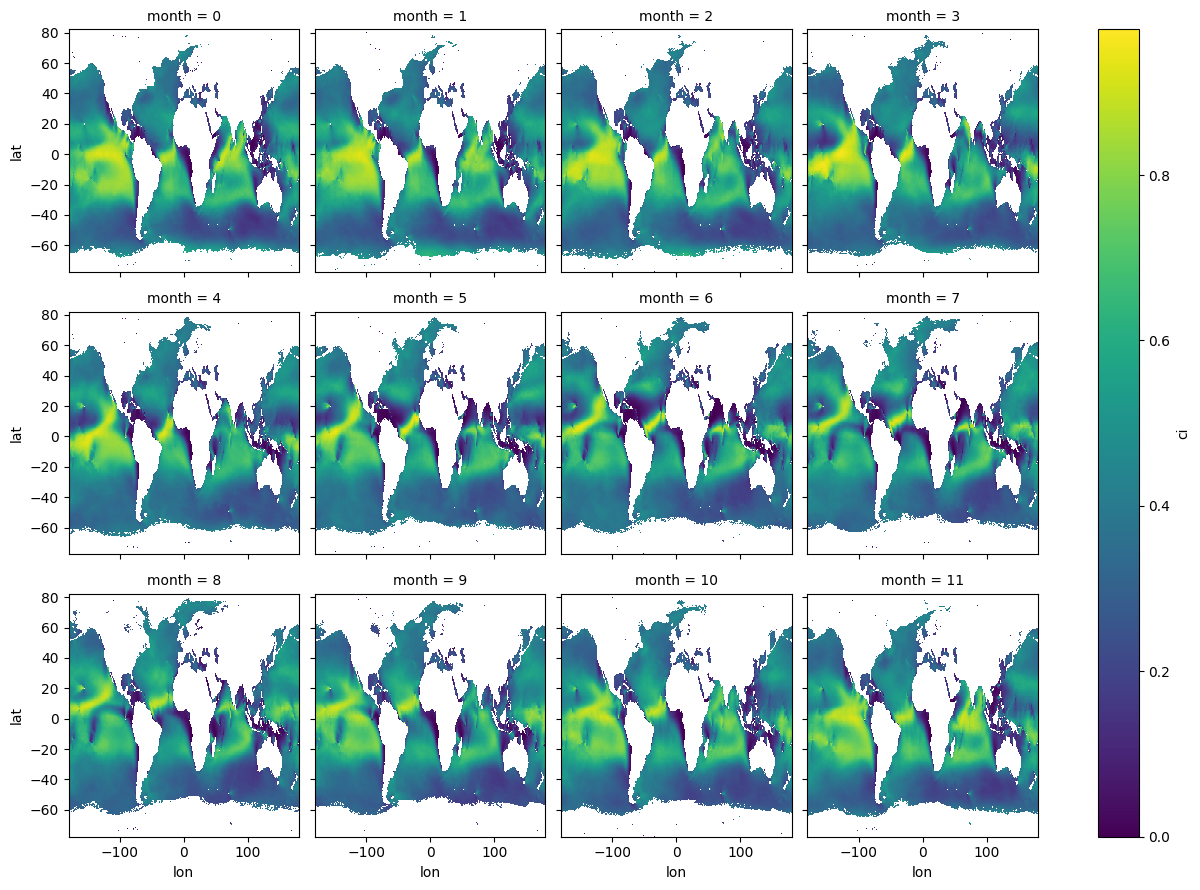

In [15]:
ds_clim.ci.plot(col="month", col_wrap=4)
print(ds_clim.ci.mean())

### How much do two systems account for total energy?

In [ ]:
def read_2par (readpath='/scratch/jw8736/wavecnn/data/', year=2008, month=1):
    # Important! Need to fill nan with 0 for phs{i} before calling get_top2_indices
    ds = xr.open_dataset(readpath + f'LOPS_WW3-GLOB-30M_{year:04d}{month:02d}.nc')
    for i in range(0, 6):
        ds[f"phs{i}"] = ds[f"phs{i}"].fillna(0)
        
    ds, idx1, idx2 = get_top2_indices(ds)
    # Wave height ratio
    ratio = ds.hs_p2 / ds.hs_p1
    # Direction difference
    dir_diff = abs(ds.dir_p1 - ds.dir_p2)
    dir_diff = xr.where(dir_diff <= 180, dir_diff, 360 - dir_diff)
    # Crossing sea criterion? 40 degree direction difference and 0.5 height ratio
    crossing = xr.where((dir_diff >= 40) & (ratio > 0.5), 1, 0)
    # Re-apply land (ice) mask
    crossing_masked = crossing.where((ds.ice < 0.1).values) 
    parts = np.stack([ds.hs_p1.values, ds.tp_p1.values, ds.dir_p1.values,
                      ds.hs_p2.values, ds.tp_p2.values, ds.dir_p2.values,
                      crossing_masked.values], axis=0)
    parts = np.swapaxes(parts, 0, 1)
    return parts

In [15]:
from wavediffusion.waveutils import get_top2_indices
readpath = '/global/homes/j/jiarongw/scratch_folder/wave_data/raw/'
annual = 0
thres = 0.9
for month in range(1,13):
    ds = xr.open_dataset(readpath + f'LOPS_WW3-GLOB-30M_2010{month:02d}.nc')
    for i in range(0, 6):
        ds[f"phs{i}"] = ds[f"phs{i}"].fillna(0)
    ds, idx1, idx2 = get_top2_indices(ds)
    ratio = ((ds.hs_p2/4)**2 + (ds.hs_p1/4)**2) / (ds.hs/4)**2
    mask = ratio.where(ds.ice == 0., drop=True)
    pct = (mask > thres).sum() / mask.count() * 100
    print(float(pct))
    annual += pct
print('Annual average percentage %g' %(annual/12))

66.1107833867015
66.14031598026124
67.7186266411434
71.29965727449355
72.4608275151165
75.56457760949968
76.96787732551782
75.80812262518432
74.62301040134547
72.42758876545629
70.21697291499058
70.47706454289305
Annual average percentage 71.6513
